In [1]:
import numpy as np
colors = [
    '#1b9e77',
    '#d95f02',
    '#7570b3'
]
def plot_env(ax,t_g,t_0, phase=0):
    # Set bottom and left spines as x and y axes of coordinate system
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

    # Create 'x' and 'y' labels placed at the end of the axes
    ax.set_xlabel('t', size=10, labelpad=-25, x=1.09, rotation=0)
    #ax.set_ylabel('a.u.', size=14, labelpad=-21, y=1.02, rotation=0)

    # Create custom major ticks to determine position of tick labels
    x_ticks_v = [t_0, t_0+t_g]
    y_ticks_m = [r"$t_0$", r"$t_0 + t_g$"]
    y_ticks = [-1, 0, 1]
    ax.set_xticks(x_ticks_v)
    ax.set_xticklabels(y_ticks_m, fontsize=10)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(['']*3, fontsize=10)
    x0, xL = -0.1, 1.3
    ax.set_xlim(x0, x0 + xL)
    y0, yL = -1.2, 2.6
    ax.set_ylim(y0, y0 + yL)
    omega_d=10

    def env_func(t):
        if t > t_0 and t < t_0+t_g:
            return 0.5-0.5*np.cos(2*np.pi*(t-t_0)/t_g)
        return 0
    def cos_func(t):
        return np.cos(np.pi*omega_d*t+phase)*env_func(t)
    X = np.linspace(-1,2,1000)
    Ye = np.array([env_func(t) for t in X])
    ax.plot(X,Ye, color=colors[1])
    ax.plot(X,-Ye, color=colors[1],alpha=0.2)
    Yc = [cos_func(t) for t in X]
    ax.plot(X,Yc, color=colors[2], alpha=0.5)
    ax.set_xlim(0,t_g+2*t_0)

import qutip as qt
def plot_bloch(ax, t_g, t_0, phase=0, n_matrix=None, phi_matrix=None, t0_count=10000):
    first = True
    fstates = []
    bloch = qt.Bloch(axes=ax)
    bloch.vector_color= []
    #make bloch axis have a transparent background
    ax.set_facecolor((0, 0, 0, 0))
    omega_d=10
    t_0_count = t0_count
    for t_0 in np.linspace(t_0,t_0+np.pi/omega_d,t_0_count):
        def env_func(t):
            if t > t_0 and t < t_0+t_g:
                return 0.25*(np.pi*t_g**-1)*(1-1*np.cos(2*np.pi*(t-t_0)/t_g))
            return 0
        def cos_func(t):
            return env_func(t)*(1+np.cos(2*np.pi*omega_d*t+2*phase))
        def sin_func(t):
            return env_func(t)*np.sin(2*np.pi*omega_d*t+2*phase)
        if n_matrix is None or phi_matrix is None:
            n = qt.sigmay()
            phi = qt.sigmax()
        else:
            n = qt.Qobj(n_matrix[:5,:5])
            phi = qt.Qobj(phi_matrix[:5,:5])
        H = lambda t: cos_func(t)*phi + sin_func(t)*n
        #make a qutip simulation of this H
        H = qt.QobjEvo(H)
        psi0 = qt.basis(len(n.full()), 0)  # ground state
        length = 10000
        if not first: length = 1000
        result = qt.sesolve(H, psi0, np.linspace(0+t_0, 2+t_0, length), [], options=qt.Options(store_states=True,max_step=0.01))
        for i,state in enumerate(result.states):
            #trunctate to a two-level system
            result.states[i] = qt.Qobj(state.full()[:2,:2])

        if first:
            states_x, states_y, states_z = \
                [qt.expect(qt.sigmax(), result.states),
                qt.expect(qt.sigmay(), result.states),
                qt.expect(qt.sigmaz(), result.states)]
            bloch.add_points([states_x, states_y, states_z])
            #bloch.add_vectors([[states_x[0], states_y[0], states_z[0]]])
            #bloch.vector_color.append(colors[0])
        finalstate = [qt.expect(qt.sigmax(), result.states[-1]),
                      qt.expect(qt.sigmay(), result.states[-1]),
                      qt.expect(qt.sigmaz(), result.states[-1])]
        fstates.append(finalstate)
        #
        
        #bloch.vector_color.append(colors[0])
        first = False
    #bloch.add_vectors(fstates,alpha=0.5)
    #instead of the built-in add_vectors, add it manually such that it supports rasterization
    for i, state in enumerate(fstates):
        #color = colors[0] if i == 0 else colors[1]
        #bloch.vector_color.append(color)
        #bloch.vector_alpha.append(5/t_0_count)
        x = state[0] * np.array([0,1])
        y = state[1] * np.array([0,1])
        z = state[2] * np.array([0,1])
        """ax.plot(x, y, z,
                color=colors[0],
                alpha=1,#5/t_0_count,
                lw=10,
                rasterized=True)"""
    #bloch.vector_color = [colors[0]]*(len(fstates)+1)
    bloch.vector_width = 1
    bloch.vector_alpha = [1] #+ [5/t_0_count]*len(fstates)
    bloch.point_size = [1]*4
    bloch.vector_style = '-'
    bloch.zlabel = ['$\\left|0\\right>$', '$\\left|1\\right>$']
    bloch.xlabel = ['$\\left|X\\right>$', '']
    bloch.ylabel = ['$\\left|Y\\right>$', '']
    bloch.xlpos = [1.3, -1.3]
    bloch.ylpos = [1.3, -1.3]
    bloch.zlpos = [1.3, -1.3]
    bloch.font_size = 8
    
    bloch.point_color = [colors[1]]*10000
    bloch.make_sphere()
    bloch.render()
    return fstates



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal
from scipy.special import eval_hermite
from math import factorial


def plot_qbt(ax):
    # Parameters
    phi_max = 10 * np.pi  # phase basis cutoff
    N = 1000  # number of grid points
    phi = np.linspace(-phi_max, phi_max, N)
    dphi = phi[1] - phi[0]
    phi_matrix = np.diag(phi)  # diagonal matrix of phase values

    def get_n(N,max, periodic=False):
        arr_fund = [-0.5/(dphi**1),0,0.5/(dphi**1)]
        arr = np.zeros((N,N))
        for i in range(N):
            for j in range(i-2,N):
                if i == j:
                    arr[i][j] = arr_fund[1]
                elif i-j == 1:
                    arr[i][j] = arr_fund[2]
                elif i-j == -1:
                    arr[i][j] = arr_fund[0]
                if j > i+1:
                    break
        if periodic:
            arr[0][-1] = arr_fund[2]
            arr[-1][0] = arr_fund[2]
        return arr
    n_matrix = get_n(N, phi_max, periodic=False)

    def get_n2(N,max, periodic=False):
        arr_fund = [1/(dphi**2),-2/(dphi**2),1/(dphi**2)]
        arr = np.zeros((N,N))
        for i in range(N):
            for j in range(i-2,N):
                if i == j:
                    arr[i][j] = arr_fund[1]
                elif i-j == 1 or i-j == -1:
                    arr[i][j] = arr_fund[0]
                if j > i+1:
                    break
        if periodic:
            arr[0][-1] = arr_fund[2]
            arr[-1][0] = arr_fund[2]
        return arr


    energies = {
        "LC circuit": {
            "EL": 1.0,  # inductive energy (in units of charging energy)
            "EC": 1.5,  # charging energy (in units of charging energy)
        },
        "Transmon": {
            "EJ": 7.0,  # Josephson energy (in units of charging energy)
            "EC": 23.0,  # charging energy (in units of charging energy)
        },
        "Fluxonium": {
            "EJ": 4.5,  # Josephson energy (in units of charging energy)
            "EL": 1.0,  # inductive energy (in units of charging energy)
            "EC": 1.0,  # charging energy (in units of charging energy)
        },
        #"Fluxonium": {#MIT fluxonium
        #    "EJ": 5.71,
        #    "EL": 0.59,
        #    "EC": 1.3
        #}
        #"Fluxonium": {#Delft fluxonium
        #    "EJ": 4.92,
        #    "EL": 0.5,
        #    "EC": 0.88
        #}
    }

    # Kinetic energy

    Ec = energies["Transmon"]["EC"]
    T_trans = -4*Ec*get_n2(N, np.pi, periodic=True)
    phi_trans = np.linspace(-np.pi, np.pi, N)
    Ec = energies["LC circuit"]["EC"]
    T_LC = -4*Ec*get_n2(N, phi_max, periodic=False)
    Ec = energies["Fluxonium"]["EC"]
    T_flux = -4*Ec*get_n2(N, phi_max, periodic=False)

    # LC circuit — simple harmonic oscillator
    V_LC = np.diag(0.5 * phi**2)

    # Transmon — cosine potential
    EJ = energies["Transmon"]["EJ"]
    V_Transmon = np.diag(-EJ * np.cos(phi_trans))

    # Fluxonium — cosine + parabolic offset (with external flux phi_ext=0)
    EL = energies["Fluxonium"]["EL"]
    EJ = energies["Fluxonium"]["EJ"]
    V_Fluxonium = np.diag(-EJ * np.cos(phi-np.pi) + 0.5 * EL * phi**2)

    # Function to diagonalize and plot eigenfunctions
    smallest_y = 0.1
    tallest_y = 1.0
    colors = [
        '#1b9e77',
        '#d95f02',
        '#7570b3'
    ]
    import pickle
    import os
    def eigs(V,T,name):
        H = V + T  # Hamiltonian
        if not os.path.exists(name+ "_H.pickle"):
            with open(name+ "_H.pickle", 'wb') as f:
                pickle.dump(np.zeros((N,N)), f)
        with open(name+ "_H.pickle", 'rb') as f:
            H_old = pickle.load(f)
            if H.shape == H_old.shape and np.allclose(H, H_old):
                print("H is the same")
                with open(name+ "_eigs.pickle", 'rb') as f:
                    evals, evecs = pickle.load(f)
            else:
                print("H is different")
                evals, evecs = np.linalg.eigh(H)
                with open(name+ "_H.pickle", 'wb') as f:
                    pickle.dump(H, f)
                with open(name+ "_eigs.pickle", 'wb') as f:
                    pickle.dump((evals, evecs), f)
        return evals, evecs
        
    from matplotlib.patches import FancyArrowPatch
    from matplotlib import ticker
    def annotate_vertical_dimension(ax, x, y1, y2, label, color='black', 
                                    text_offset=0.05, linewidth=0.8, tick_size=0.3, topbot = "top"):
        # Ensure y1 is lower than y2
        y_lower, y_upper = sorted([y1, y2])

        

        # Horizontal ticks
        ax.plot([x - tick_size-0.05, x + tick_size], [y_lower, y_lower], color=color, linewidth=linewidth)
        ax.plot([x - tick_size-0.05, x + tick_size], [y_upper, y_upper], color=color, linewidth=linewidth)


        # Rotated label at the center
        avg = (y_lower + y_upper) / 2
        if np.abs(y1-y2) > 1:
            ax.text(x+0.05, avg+0.05, r'{}'.format(label),
                    color=color, va='center', ha='center', rotation=0, fontsize=8)
            # Vertical line
            #ax.plot([x, x], [y_lower, avg-0.5], color=color, linewidth=linewidth)
            #ax.plot([x, x], [avg+0.5, y_upper], color=color, linewidth=linewidth)
            #add arrow in between
            """ax.annotate('', xy=(x, y_upper+0.25), xytext=(x, avg+0.5),
                        arrowprops=ArrowStyle('Fancy',head_length=0.5, tail_width=linewidth),
                        va='center', ha='center', fontsize=12)"""
            ax.add_patch(FancyArrowPatch((x, avg+0.5), (x, y_upper+0.15),
                        arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))

            """ax.annotate('', xy=(x, y_lower-0.25), xytext=(x, avg-0.5),
                        arrowprops=dict(arrowstyle='-|>', color=color, lw=linewidth),
                        va='center', ha='center', fontsize=12)"""
            ax.add_patch(FancyArrowPatch((x, avg-0.5), (x, y_lower-0.15),
                        arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))
            
        else:
            y = y_upper+0.1
            a = "bottom"
            if topbot == "bot":
                y = y_lower-0.1
                a = "top"
            ax.text(x+0.2, y, r'{}'.format(label),
                    color=color, va=a, ha='left', rotation=0,fontsize=8)
            # Vertical line
            ax.plot([x-0.01, x-0.01], [y_lower, y_upper], color=color, linewidth=linewidth)
            # add arrows pointing inwards
            ax.add_patch(FancyArrowPatch((x, y_upper+1.7), (x, y_upper),
                        arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))
            ax.add_patch(FancyArrowPatch((x, y_lower-1.7), (x, y_lower),
                        arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))

    def plot_eigenfunctions(phi, V, T, title, ax, n_levels=6):
        global smallest_y, tallest_y, colors    
        H = V + T  # Hamiltonian
        #evals, evecs = np.linalg.eigh(H)  # Eigenvalues and eigenvectors
        if "Transmon" in title:
            ext = np.pi
        else:
            ext = 2.1*np.pi
        evals, evecs = eigs(V,T,title)
        # Normalize eigenvectors
        for i in range(len(evecs[0,:])):
            evecs[:,i] /= np.sqrt(np.sum(evecs[:,i]**2)*dphi)
            if "Transmon" in title:
                evecs[:,i] *=2
        #make the unidirectional
        for i in range(len(evecs[:,])):
            for j in range(len(evecs[0,:])):
                if not np.isclose(evecs[j,i], 0):
                    evecs[:,i] /= np.sign(evecs[j,i])
                    break

        V_min = np.min(V)
        evals -= V_min  # Shift eigenvalues to start from zero
        V = V - V_min  # Shift potential to start from zero


        B = evecs
        #V = B @ V @ B.T
        #H = B @ H @ B.T
        

        anotcords = []
        for n in range(n_levels):
            ax.plot(phi, evecs[:, n]*2 + evals[n], label=f'n={n}', color=colors[n%3], alpha=np.exp(-n*3e-1))
            ax.fill_between(phi, evals[n], evals[n] + evecs[:, n]*2, color=colors[n%3], alpha=0.2*np.exp(-n*3e-1))
            ax.plot(phi, [evals[n]]*len(phi), color=colors[n%3], alpha=0.2*np.exp(-n*3e-1))
            va = "center"
            ofs = 0.0
            if "Fluxonium" in title:
                if n == 0:
                    va = "top"
                    ofs = 0.05
                elif n == 1:
                    va = "bottom"
                    ofs = -0.05
            anotcords.append(evals[n])
        while np.any(np.abs(np.diff(anotcords)) < 0.14*(evals[4]-evals[0])):
            for n in range(n_levels):
                if np.abs(anotcords[n] - anotcords[n-1]) < 0.15*(evals[4]-evals[0]) and n > 0:
                    anotcords[n-1] -= 0.01
                    anotcords[n] += 0.01
        for n in range(n_levels):
            ax.annotate(
                rf'$|{n}\rangle$', xy=(0, anotcords[n]), xytext=(-4.10*ext/np.pi, anotcords[n]+(evecs[:, n]*2)[-1]),    
                fontsize=8, color="k", ha='left', va=va)
        ax.plot(phi, np.diag(V), 'k', label='Potential')
        #ax.set_title(title, fontsize=12)
        ax.set_xlabel(r'$\phi$', fontsize=10)

        #anharmonicity
        if "LC" not in title:
            phi_capped = np.linspace(-ext*0.9, ext*0.9, 10)
            ax.plot(phi_capped, [evals[0]+2*(evals[1]-evals[0])]*len(phi_capped), 'k--', alpha=0.5, zorder=-20)
            ts = 0.3
            if "Transmon" in title:
                ts /= 2.0
            x_shift_alpha = -1
            x_shift_omega = 0
            annotate_vertical_dimension(ax, 2.8*ext/np.pi+x_shift_alpha, evals[2], evals[0]+2*(evals[1]-evals[0]), r'$\alpha$', color='k', text_offset=0.1, tick_size=ts, topbot = "top")
            annotate_vertical_dimension(ax, 2.8*ext/np.pi+x_shift_omega, evals[1], evals[0], r'$\omega_{01}$', color='k', text_offset=0.2, tick_size=ts, topbot = "bot")
            print(f'{title} anharmonicity: {(evals[2]-evals[1])-(evals[1]-evals[0]):.2f} GHz')
            print(rf'{title} $\omega_{{01}}$: {(evals[1]-evals[0])} GHz')
        
        #ax.grid(True)
        #ax.set_xlim(-phi_max/2, phi_max/2)
        smallest_y = 0.1
        tallest_y = evals[n_levels-1]
        if evals[0] < smallest_y:
            smallest_y = evals[0]
        if evals[n_levels-1] > tallest_y:
            tallest_y = evals[n_levels-1]
        ax.set_ylim([smallest_y-0.05*(tallest_y-smallest_y), tallest_y*0.5])#her
        ax.set_xlim(-ext, ext)
        if "LC" in title:
            ax.set_ylabel('Energy levels [GHz]',fontsize=10)

        #set tick font size
        for tick in ax.xaxis.get_major_ticks():
            tick.label1.set_fontsize(10)
            tick.label2.set_fontsize(10)
        for tick in ax.yaxis.get_major_ticks():
            tick.label1.set_fontsize(10)
            tick.label2.set_fontsize(10)
        
        #set x-axis ticks in units of pi
        span = [-ext, ext]
        loc = ticker.MultipleLocator(np.pi)
        ax.xaxis.set_major_locator(loc)
        def func_format(x,_):
            string = f'{x/np.pi:.0f} $\pi$' if x != 0 else '0'
            if x/np.pi == 1:
                string = r'$\pi$'
            elif x/np.pi == -1:
                string = r'$-\pi$'
            return string
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(func_format))
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(np.pi/2))
        return B
    
    diagonalizer = plot_eigenfunctions(phi, V_Fluxonium, T_flux, 'Fluxonium', ax)
    phi_matrix = diagonalizer.T @ phi_matrix @ diagonalizer
    n_matrix = diagonalizer.T @ n_matrix @ diagonalizer
    return phi_matrix, n_matrix
    
#import locator
import matplotlib.ticker as ticker
def plot_cartoon(ax, t_gs, alphas, markerstuff):
    ax.set_xlabel(r"$\omega_{01} t_g/2\pi$",labelpad=0.0)
    ax.set_ylabel(r"$\alpha/\omega_{01}$", labelpad=0.0)
    ax.set_xlim(-1,2)
    ax.set_ylim(-0.5, 1.5)

    #turn on axis
    ax.set_axis_on()

    #make logs-style ticks
    #ax.set_xticks([-1, 0, 1, 2],major=True)
    #ax.set_xticklabels(['$10^{-1}$', '$10^0$', '$10^1$', '$10^2$'], major=True)
    #ax.set_yticks([-1, 0, 1], major=True)
    #ax.set_yticklabels(['$10^{-1}$', '$10^0$', '$10^1$'], major=True)
    #make logstyle minor ticks
    #manually set minor ticks logstyle
    baseticks = np.log10(np.array(range(10)))
    minorticks = np.concatenate([baseticks + i for i in range(-1, 3)])
    ax.set_xticks(minorticks, minor=True)
    ax.set_yticks(minorticks, minor=True)
    major_ticks = np.array([-1, 0, 1, 2])
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    def logformatter(x):
        if x == 0:
            return '1'
        elif x == 1:
            return '10'
        else:
            return f'$10^{{{int(x)}}}$'
    ax.set_xticklabels([logformatter(x) for x in major_ticks])
    ax.set_yticklabels([logformatter(x) for x in major_ticks])
    ax.set_xlim(np.log10(0.2),np.log10(80))
    ax.set_ylim(np.log10(0.2),np.log10(20))
    
    

    #lines [(startcord), (endcord)]
    alphaline = [(np.log10(0.2),np.log10(8)),(np.log10(70),np.log10(0.2))]
    omegaline = [(0,-1), (0,np.log10(20))]
    decayline = [(1.5,-1),(1.5,np.log10(20))]

    #find intersections with alphaline
    def find_intersection(line1, line2):
        x1, y1 = line1[0]
        x2, y2 = line1[1]
        x3, y3 = line2[0]
        x4, y4 = line2[1]
        xs = np.array([x1, x2, x3, x4], dtype=float)
        xs += np.random.uniform(-0.000001, 0.000001, 4)  # add some noise to avoid numerical issues
        x1, x2, x3, x4 = xs
        a1 = (y2 - y1) / (x2 - x1)
        b1 = y1 - a1 * x1
        a2 = (y4 - y3) / (x4 - x3)
        b2 = y3 - a2 * x3
        if a1 == a2:  # lines are parallel
            return None
        x_intersect = (b2 - b1) / (a1 - a2)
        y_intersect = a1 * x_intersect + b1
        return (x_intersect, y_intersect)
    #partition lines by their intersections
    intersection_alpha1 = find_intersection(alphaline, omegaline)
    intersection_alpha2 = find_intersection(alphaline, decayline)
    alphaline_new = []
    if intersection_alpha1 is not None:
        alphaline_new.append([(alphaline[0][0], alphaline[0][1]), intersection_alpha1])
        if intersection_alpha2 is not None:
            alphaline_new.append([intersection_alpha1, intersection_alpha2])
            alphaline_new.append([intersection_alpha2, (alphaline[1][0], alphaline[1][1])])
        else:
            alphaline_new.append([intersection_alpha1, (alphaline[1][0], alphaline[1][1])])
    else:
        alphaline_new.append([alphaline[0], alphaline[1]])
    omegaline_new = []
    intersection_omega1 = intersection_alpha1
    intersection_omega2 = None
    if intersection_omega1 is not None:
        omegaline_new.append([(omegaline[0][0], omegaline[0][1]), intersection_omega1])
        if intersection_omega2 is not None:
            omegaline_new.append([intersection_omega1, intersection_omega2])
            omegaline_new.append([intersection_omega2, (omegaline[1][0], omegaline[1][1])])
        else:
            omegaline_new.append([intersection_omega1, (omegaline[1][0], omegaline[1][1])])
    else:
        omegaline_new.append([omegaline[0], omegaline[1]])
    decayline_new = []
    intersection_decay1 = intersection_alpha2
    intersection_decay2 = None
    if intersection_decay1 is not None:
        decayline_new.append([(decayline[0][0], decayline[0][1]), intersection_decay1])
        if intersection_decay2 is not None:
            decayline_new.append([intersection_decay1, intersection_decay2])
            decayline_new.append([intersection_decay2, (decayline[1][0], decayline[1][1])])
        else:
            decayline_new.append([intersection_decay1, (decayline[1][0], decayline[1][1])])
    else:
        decayline_new.append([decayline[0], decayline[1]])
    #plot lines
    for i,line in enumerate(alphaline_new):
        if i == 0 or i == 2:
            ls = "--"
        else:
            ls = "-"
        ax.plot([line[0][0], line[1][0]], [line[0][1], line[1][1]], color="k", linestyle=ls)
    for i,line in enumerate(omegaline_new):
        if i == 0:
            ls = "--"
        else:
            ls = "-"
        ax.plot([line[0][0], line[1][0]], [line[0][1], line[1][1]], color="k", linestyle=ls)
    for i,line in enumerate(decayline_new):
        if i == 0:
            ls = "--"
        else:
            ls = "-"
        ax.plot([line[0][0], line[1][0]], [line[0][1], line[1][1]], color="k", linestyle=ls)
    #use the alpha intersection as coordinates for an fill-between method
    maxy = ax.get_ylim()[1]
    miny = ax.get_ylim()[0]
    minx = ax.get_xlim()[0]
    maxx = ax.get_xlim()[1]
    line_x, line_lower_y = [intersection_alpha1[0], intersection_alpha2[0]], [intersection_alpha1[1], intersection_alpha2[1]]
    line_upper_y = [maxy, maxy]
    cmap = plt.get_cmap("viridis")
    c_perf = cmap(0.95)
    #ax.fill_between(line_x, line_lower_y, line_upper_y, color=c_perf, alpha=1, label=r"Performant region")
    line_np_x, line_np_lower_y = [minx,intersection_alpha1[0],intersection_alpha1[0],intersection_alpha2[0],intersection_alpha2[0], maxx], [miny,miny,miny, miny, miny, miny]
    line_np_upper_y = [maxy,maxy, intersection_alpha1[1], intersection_alpha2[1], maxy, maxy]
    c_nonperf = cmap(0.1)
    #ax.fill_between(line_np_x, line_np_lower_y, line_np_upper_y, color=c_nonperf, alpha=1, label=r"Non-performant region")
    #instead of fillbetween, use showimg, in order to convolute the transitions
    X = np.linspace(minx, maxx, 1000)
    Y = np.linspace(miny, maxy, 1000)
    Z = np.zeros((len(X), len(Y)))
    for i,x in enumerate(X):
        intervalindx = 0
        while intervalindx+1 < len(line_np_x) and line_np_x[intervalindx+1] < x:
            intervalindx += 1
        x1 = line_np_x[intervalindx]
        y1 = line_np_upper_y[intervalindx]
        if intervalindx+1 >= len(line_np_x):
            x2 = 100
            y2 = line_np_upper_y[intervalindx]
        else:
            x2 = line_np_x[intervalindx+1]
            y2 = line_np_upper_y[intervalindx+1]
        a = (y2 - y1) / (x2 - x1)
        b = y1 - a * x1
        y_thresh = a * x + b
        mask_over = Y > y_thresh
        Z[i, mask_over] = 1.0
        Z[i, ~mask_over] = 0.2
    #make a gausian filter
    from scipy.ndimage import gaussian_filter
    Z = gaussian_filter(Z, sigma=50)
    Z = np.clip(Z, 0, 1)  # Ensure values are between 0 and 1
    Z = Z.T  # Transpose to match the shape for imshow
    ax.imshow(Z, extent=(minx, maxx, miny, maxy), origin="lower", cmap="plasma", alpha=1)

    #annotate at the lines what they represent
    ax.annotate('RW', xy=(omegaline[1][0], omegaline[1][1]), xytext=(omegaline[1][0], omegaline[1][1]),
                fontsize=10, color="k", ha='right', va='bottom')
    ax.annotate(r'Decay', xy=((decayline[1][0]+np.log10(80))/2, decayline[1][1]), xytext=(decayline[1][0], decayline[1][1]),
                fontsize=10, color="k", ha='center', va='bottom')
    x, y = (alphaline[0][0] + alphaline[1][0]) / 2, (alphaline[0][1] + alphaline[1][1]) / 2
    ax.annotate(r'$\alpha$', xy=(x, y), xytext=(x+0.1, y+0),
                fontsize=10, color="k", ha='left', va='bottom')
    
    #anotate alpha and tg
    """markers = [#suare and triangle
        "s",
        "^",
    ]"""
    for tg,alpha,i in zip(t_gs, alphas, range(len(t_gs))):
        x,y = np.log10(tg*2*np.pi), np.log10(alpha)
        #make a cross
        ax.plot(x, y, marker=markerstuff['markers'][i], color=colors[0], markersize=markerstuff['marker_sizes'][i])



H is the same
Fluxonium anharmonicity: 3.24 GHz
Fluxonium $\omega_{01}$: 0.4452510793213489 GHz


/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


NameError: name 'y0' is not defined

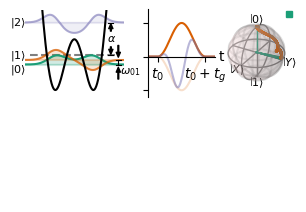

In [4]:
from matplotlib import rcParams


def do(t_0cnt=5000):
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    import numpy as np
    from matplotlib import rcParams

    rcParams['font.size'] = 8  # Sets default font size for most text
    rcParams['axes.titlesize'] = 8 # Sets title font size
    rcParams['axes.labelsize'] = 8 # Sets axis label font size
    rcParams['xtick.labelsize'] = 8 # Sets x-tick label font size
    rcParams['ytick.labelsize'] = 8 # Sets y-tick label font size
    

    fig = plt.figure(figsize=(3.5, 2.5))

    # Define a GridSpec with 2 rows and 2 columns
    # Left column: two axes stacked vertically, with variable height
    # Right column: two axes stacked vertically, equal height
    gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1], width_ratios=[1, 1.5])

    # Left top (bigger)
    ax3 = fig.add_subplot(gs[0, 0])

    # Left bottom (smaller)
    ax4 = fig.add_subplot(gs[1, 0])

    # Right top (equal height)
    ax1 = fig.add_subplot(gs[0, 1])

    # Right bottom (equal height)
    ax2 = fig.add_subplot(gs[1, 1])

    # Draw rectangles to see the layout
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xticks([])
        ax.set_yticks([])
        """for spine in ax.spines.values():
            spine.set_edgecolor('black')"""
        ax.set_axis_off()

    phi_matrix, n_matrix = plot_qbt(ax3)
    phi_matrix /= np.abs(phi_matrix[0,1])
    n_matrix /= np.abs(n_matrix[0,1])

    #add two subplots to the left column
    pulse_axes = [ax1, ax2]
    t_0_s = [0.05, 0.07]
    t_g_s = [0.25, 0.12]
    alphas = [4, 2.5]
    markers = ['s', '^']  # square and triangle markers
    marker_sizes = [5, 6]
    phase = -1.5
    cnt = 0
    phase2 = 1.5
    for ax, t_0, t_g, alpha, marker, ms in zip(pulse_axes, t_0_s, t_g_s, alphas, markers, marker_sizes):
        if cnt == 1: phase += phase2
        subAx1 = ax.inset_axes([0.0, 0.0, 0.45, 1])  # inset axes
        subAx2 = ax.inset_axes([0.5, 0.0, 0.45, 1], projection='3d')  # inset axes
        subAxes = [subAx1, subAx2]
        #do this in a smart way instead of using inset_axes
        pulseAx = subAxes[0]
        blochAx = subAxes[1]

        

        plot_env(pulseAx, t_g, t_0, phase=phase)

        #blochAx.set_axis_off()
        fstates = plot_bloch(blochAx, t_g, t_0, phase=phase, n_matrix=n_matrix, phi_matrix=phi_matrix, t0_count=t_0cnt)
        #manually plot the fstates
        for i, fstate in enumerate(fstates):
            x = fstate[1] * np.array([0,1])
            y = fstate[0] * np.array([0,1])
            z = fstate[2] * np.array([0,1])
            blochAx.plot(x, y, z, 
                         lw=1, color=colors[0],alpha=10/t_0cnt,
                         rasterized=True)
        blochAx.plot([0,0],[0,0],[0,1], lw=1, color=colors[0], alpha=1)

        #put a marker in the top right corner
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.plot(0.95, 0.95, marker=marker, color=colors[0], markersize=ms, label=f'$t_g={t_g}$, $\alpha={alpha}$')



        # Draw arrows
        arrow_fmt = dict(markersize=4, color='black', clip_on=False)
        pulseAx.plot((0.45), (-y0/yL), marker='>', transform=ax.get_yaxis_transform(), **arrow_fmt)
        pulseAx.plot((-0), (1), marker='^', transform=ax.get_xaxis_transform(), **arrow_fmt)
        cnt += 1



    plot_cartoon(ax4, t_g_s, alphas, markerstuff={"markers": markers, "marker_sizes": marker_sizes})


    plt.tight_layout(
        rect=[0, 0, 1, 1],  # Adjust the rectangle to fit the figure
        h_pad=00,  # Adjust vertical padding between subplots
        w_pad=00,  # Adjust horizontal padding between subplots
    )
    plt.savefig('figures/Figure1.pdf', bbox_inches='tight', dpi=300)
    plt.savefig('figures/Figure1.png', bbox_inches='tight', dpi=300)
    plt.show()

do(t_0cnt = 100)
